<a href="https://colab.research.google.com/github/migikai15/AI_2026S1_Exercicio_Keras.ipynb/blob/main/AI_2026S1_Exercicio_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classificação de Imagens com Keras/TensorFlow Sequential**





In [ ]:
#@markdown >
#@markdown **Atividade INDIVIDUAL ou EM DUPLA**
#@markdown
#@markdown > Nome **COMPLETO** e RA

Aluno1 = '' #@param {type:"string"}
RA1 = '' #@param {type:"string"}
#@markdown
Aluno2 = '' #@param {type:"string"}
RA2 = '' #@param {type:"string"}

suffix_file_1 = RA1.replace('.','')
suffix_file_2 = RA2.replace('.','')


# **Exercício**

1. Atividade **INDIVIDUAL OU em DUPLA**
2. Apenas **UM ALUNO DEVE POSTAR**
3. Postar o **notebook Python (arquivo .ipynb) 100% executável**

O arquivo abaixo contem imagens de dois tipos de flores (rosas e dentes de leão). As imagens estão em formato 180x180x1, isto é imagens 180x180 com um único canal (não RGB). As imagens de rosas e dentes de leão estão pastas separadas, o que pode ser empregado para construção de rótulos de classificação.



## Parte I
Empregue o Keras/TensorFlow para construir um modelo MLP (Multi Layer Perceptron, isto é, um modelo Sequencial do Keras/TensorFlow, somente com camadas densas(\*) de aprendizado de classificação das imagens. Isso pode ser feito linearizando as imagens 180x180 em arrays de tamanho 32400.

Esquematicamente o seu conjunto de exemplos será o seguinte:

```
            32400 array      classe
          _____________________________
imagem_1  1001010011100...  roses
imagem_2  1001010011100...  dandelion
imagem_3  1001010011100...  roses
imagem_4  1001010011100...  roses
imagem_5  1001010011100...  dandelion
...
```

Você pode empregar este notebook [TensorFlow: Penguins Example](https://colab.research.google.com/github/Rogerio-mack/IA_2026S1/blob/main/TensorFlow_Penguins_Example.ipynb) como exemplo/ponto de partida.

Organize adequadamente o seu notebook, com uma seção para cada um dos itens abaixo, colocando um texto mínimo explicativo (markdown) de cada seção:

1. Preparação dos dados (incluindo separação dos dados de treinamento e teste)
2. Configuração do Modelo Sequencial Denso
3. Treinamento do Modelo
4. Histórico do Treinamento (gráfico de evolução)
5. Classification Report





<br>
<br>

<small>
(*) Note que um modelo Multi Layer Perceptron, um modelo Sequencial do Keras/TensorFlow, somente com camadas densas <strong>não possui camadas de convolução.</strong>)

<br>
<br>


## Parte II

Execute a mesma classificação empregando o modelo de rede convolucional apresentado no [Tutorial de  Classificação de Imagens do Keras](https://www.tensorflow.org/tutorials/images/classification?hl=pt-br) e compare os resultados com os do modelo anterior.

```
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])
```

Faça o código desta parte em uma única seção e ao final uma seção de conclusão analisando os resultados.

1. Modelo Convolucional
2. Conclusão


## Dados

In [2]:
!wget https://github.com/Rogerio-mack/IA_2026S1/raw/refs/heads/main/grayscale_flower_photos_180x180.zip


--2026-05-26 17:26:25--  https://github.com/Rogerio-mack/IA_2026S1/raw/refs/heads/main/grayscale_flower_photos_180x180.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Rogerio-mack/IA_2026S1/refs/heads/main/grayscale_flower_photos_180x180.zip [following]
--2026-05-26 17:26:25--  https://raw.githubusercontent.com/Rogerio-mack/IA_2026S1/refs/heads/main/grayscale_flower_photos_180x180.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22327970 (21M) [application/zip]
Saving to: ‘grayscale_flower_photos_180x180.zip’

grayscale_flower_ph 100%[===================>]  21.29M  --.-KB/s    in 0.1s    

In [3]:
!unzip -q /content/grayscale_flower_photos_180x180.zip

## Exemplos dos dados de Treinamento

Note, alguns pode parecer bastante estranhos, mas é um conjunto de dados real.

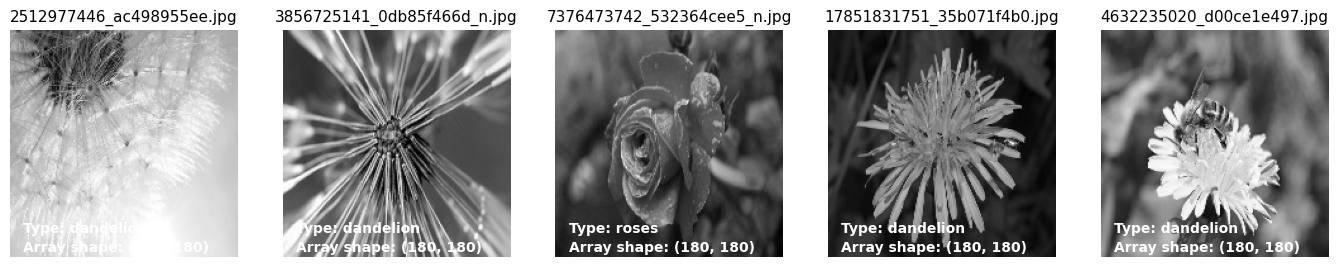

In [4]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pathlib

data_dir = pathlib.Path('/content/content/grayscale_flower_photos_180x180')

# List all image paths
image_paths = []
for class_dir in data_dir.iterdir():
    if class_dir.is_dir():
        for image_path in class_dir.glob('*.jpg'):
            image_paths.append(image_path)

if not image_paths:
    print(f"No images found in {data_dir}. Please ensure images have been processed and saved.")
else:
    plt.figure(figsize=(17, 4))
    for i in range(5):
      plt.subplot(1, 5, i + 1)
      random_image_path = random.choice(image_paths)
      img_array = mpimg.imread(str(random_image_path))

      plt.imshow(img_array, cmap='gray') # Use 'gray' colormap for grayscale images
      plt.title(f"{random_image_path.name}",fontsize=11)
      plt.text(10,175,f"Array shape: {img_array.shape}",color='white',fontsize=10,weight='bold')
      plt.text(10,160,f"Type: {str(random_image_path).split('/')[-2]}",color='white',fontsize=10,weight='bold')
      plt.axis('off')

    plt.show()

## **1. Preparação dos dados**

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import pathlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Caminho para os dados (verifique o caminho exato no seu Colab)
data_dir = pathlib.Path('/content/content/grayscale_flower_photos_180x180')
if not data_dir.exists():
    data_dir = pathlib.Path('/content/grayscale_flower_photos_180x180')

batch_size = 32
img_height = 180
img_width = 180

# Dados de Treino
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode="grayscale")

# Dados de Teste/Validação
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode="grayscale")

class_names = train_ds.class_names
print("Classes disponíveis:", class_names)

Found 1539 files belonging to 2 classes.
Using 1232 files for training.
Found 1539 files belonging to 2 classes.
Using 307 files for validation.
Classes disponíveis: ['dandelion', 'roses']


## **2. Configuração do Modelo Sequencial Denso**





In [6]:
num_classes = len(class_names)

model_mlp = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 1)),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(64, activation='relu'),
  layers.Dense(num_classes)
])

model_mlp.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,147,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,155,714 (15.85 MB)

 Trainable params: 4,155,714 (15.85 MB)

 Non-trainable params: 0 (0.00 B)

## **3. Treinamento do Modelo**


In [7]:
epochs = 10
history_mlp = model_mlp.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5617 - loss: 1.3653 - val_accuracy: 0.4072 - val_loss: 1.4654
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5852 - loss: 1.0380 - val_accuracy: 0.4788 - val_loss: 0.7602
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6055 - loss: 0.9103 - val_accuracy: 0.6026 - val_loss: 0.7757
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6705 - loss: 0.6542 - val_accuracy: 0.5928 - val_loss: 1.0453
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6753 - loss: 0.6774 - val_accuracy: 0.6221 - val_loss: 0.8802
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6640 - loss: 0.7404 - val_accuracy: 0.6026 - val_loss: 1.0555
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7070 - loss: 0.5885 - val_accuracy: 0.5765 - val_loss: 0.7529
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7240 - loss: 0.5726 - val_accuracy: 0.5407 - v

## **4. Histórico do Treinamento**


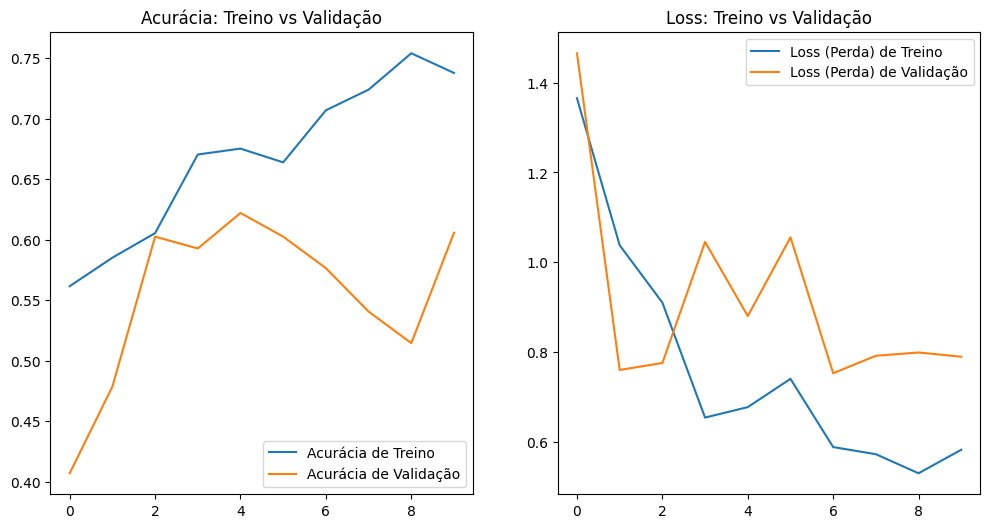

In [8]:
acc = history_mlp.history['accuracy']
val_acc = history_mlp.history['val_accuracy']
loss = history_mlp.history['loss']
val_loss = history_mlp.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, label='Acurácia de Validação')
plt.legend(loc='lower right')
plt.title('Acurácia: Treino vs Validação')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss (Perda) de Treino')
plt.plot(epochs_range, val_loss, label='Loss (Perda) de Validação')
plt.legend(loc='upper right')
plt.title('Loss: Treino vs Validação')
plt.show()

## **5. Classification Report**

In [9]:
y_true = []
y_pred_probs = []

# Iterar sobre o dataset de validação para recolher as previsões
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model_mlp.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report - MLP:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report - MLP:
              precision    recall  f1-score   support

   dandelion       0.62      0.85      0.72       181
       roses       0.54      0.26      0.35       126

    accuracy                           0.61       307
   macro avg       0.58      0.55      0.53       307
weighted avg       0.59      0.61      0.57       307



## **6. Modelo Convolucional**

In [10]:
model_cnn = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 1)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model_cnn.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_cnn.summary()

# Treino do modelo Convolucional
epochs_cnn = 10
history_cnn = model_cnn.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs_cnn
)

# Relatório de Classificação da CNN
y_pred_cnn_probs = []
for images, _ in val_ds:
    preds = model_cnn.predict(images, verbose=0)
    y_pred_cnn_probs.extend(preds)

y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

print("\nClassification Report - CNN:")
print(classification_report(y_true, y_pred_cnn, target_names=class_names))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,610 (15.22 MB)

 Trainable params: 3,988,610 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.6023 - loss: 0.6770 - val_accuracy: 0.6645 - val_loss: 0.6077
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6997 - loss: 0.5608 - val_accuracy: 0.7134 - val_loss: 0.5622
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7670 - loss: 0.4820 - val_accuracy: 0.7068 - val_loss: 0.5584
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8125 - loss: 0.4123 - val_accuracy: 0.7166 - val_loss: 0.5765
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8636 - loss: 0.3283 - val_accuracy: 0.7264 - val_loss: 0.5932
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9213 - loss: 0.2277 - val_accuracy: 0.7459 - val_loss: 0.6387
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9529 - loss: 0.1362 - val_accuracy: 0.7166 - val_loss: 0.8249
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9635 - loss: 0.0946 - val_accuracy: 0.7557 -

## **7. Conclusão**

In [11]:
Ao analisar os resultados, nota-se que o modelo Convolucional (CNN) tende a apresentar uma melhoria substancial no desempenho (acurácia e F1-score) em comparação com o modelo Multi Layer Perceptron (MLP)
estritamente denso.O modelo MLP sofre porque é forçado a linearizar (Achatar/Flatten) uma imagem de 180x180 em um array unidimensional de 32.400 posições antes mesmo da primeira camada de processamento.
Isto faz com que se perca por completo a relação espacial e estrutural dos píxeis (como formas, texturas e contornos das pétalas ou folhas). Por outro lado, as camadas de Convolução e MaxPooling na CNN são
capazes de extrair essas características espaciais bidimensionais de forma progressiva e eficaz, exigindo menos parâmetros gerais para treinar e mitigando muito melhor a sobre-adaptação (overfitting) em tarefas de
visão computacional.